# Chapter 19 — Thermal Effects on Strain
### *Modern Strain Gage Technology* — Companion Notebook

**Temperature is the strain gage's most persistent adversary.** A gage bonded to a structure and exposed to a temperature change reports a resistance change even when the structure carries no mechanical load at all.

*Companion notebook to Chapter 19 — Thermal Effects on Strain.*

That reading is the chapter's **thermal output** (older literature calls it *apparent strain*, a term now largely retired). It arises from two sources: the temperature coefficient of resistance of the gage alloy, and the mismatch between the thermal expansion coefficients of the gage grid and the specimen material. When these effects combine unfavorably, thermal outputs of hundreds of microstrain over a modest temperature excursion are routine, easily swamping the mechanical signal of interest.

Note what thermal output is *not*: it is not the specimen's free thermal expansion. A bar of steel heated 50 °C genuinely grows by 600 µε, but a correctly compensated gage bonded to it reads close to *zero*. The structure's deformation and the instrument's response are different quantities, and keeping them apart is the whole business of this chapter.

This notebook quantifies thermal output across five common specimen materials, works a numerical example of self-temperature-compensation (STC) mismatch on aluminum, and shows how the dummy-gage technique cancels thermal output at the bridge level — with no post-processing at all.

**This notebook demonstrates:**
1. Thermal output vs. temperature for five materials measured with one steel-matched (STC-06) gage
2. STC mismatch error — a steel-matched gage on aluminum, referenced to the +24 °C balance point
3. Dummy-gage correction — a numerical comparison of quarter-bridge error vs. half-bridge accuracy
4. Thermal output by grid alloy — constantan (A-alloy) vs. modified Karma (K-alloy), from published polynomials for two real STC-06 gage lots

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book includes these exact filenames.
OUT_DIR = Path("../src/media/ch19")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# This notebook is fully deterministic (no random data), so no seeding is
# required. Every curve below is reproducible byte-for-byte from these inputs.

---
## 1 — Thermal Output vs. Temperature

Chapter 19 writes thermal output as the sum of two temperature-driven terms (Eq. 19.1). The first is the temperature coefficient of resistance (TCR) of the grid alloy, divided by the gage factor — the direct resistance change of the grid with temperature. The second is the differential thermal expansion between the specimen and the grid. Because the grid is bonded to the specimen, it is forced to follow the substrate: **if the specimen expands faster than the grid would on its own, the grid is stretched into tension, which *raises* its resistance and registers as positive thermal output.** In symbols the mismatch term is proportional to $(\alpha_s - \alpha_g)$ — substrate CTE minus grid CTE — exactly the sign the chapter's Eq. 19.1 carries.

A **self-temperature-compensating (STC)** gage exploits this. The alloy is metallurgically processed so that the TCR term and the expansion-mismatch term cancel *for one particular substrate CTE* — the gage's **STC-match CTE**.

**Compensation is not cancellation.** It is tempting to write the residual as $\varepsilon_{T/O} \approx (\alpha_s - \alpha_{\text{STC}})\,\Delta T$ and stop there, but that first-order form has two artifacts that matter. It makes every curve a straight line through the origin, and it pins the matched material to *exactly* zero at every temperature. Neither is true. The TCR term $\beta_G$ is itself strongly temperature dependent, so real thermal output is a smooth nonlinear curve — near zero over a band around the $+24$ °C reference where the bridge was balanced, then bowing away at both extremes. That is the shape Micro-Measurements publishes in TN-504, and the shape Figure 19.3 reproduces.

The model below therefore anchors the compensated residual on the TN-504 constantan characteristic and superimposes the expansion-mismatch term on top of it. The matched steel curve is flat *near* the reference and departs from zero at the extremes; everything else fans out from there.

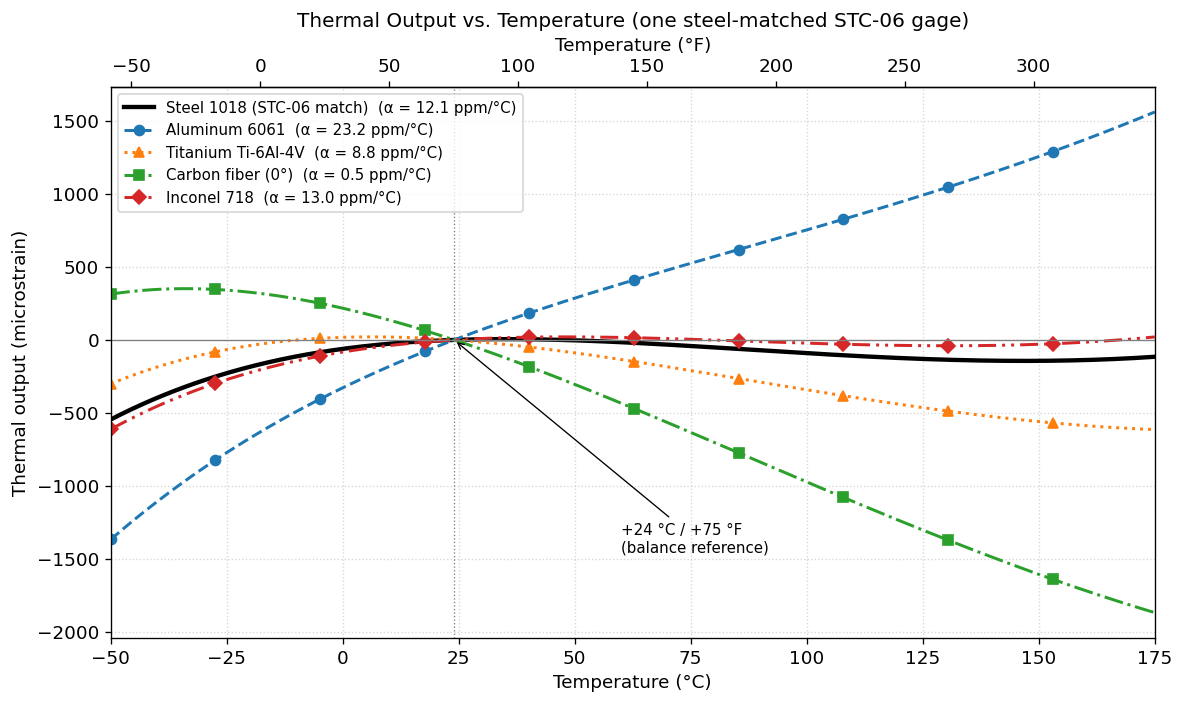

T =    -50 degC   matched STC-06 on 1018 steel:    -545 microstrain
T =     24 degC   matched STC-06 on 1018 steel:       0 microstrain
T =    100 degC   matched STC-06 on 1018 steel:     -91 microstrain
T =    175 degC   matched STC-06 on 1018 steel:    -115 microstrain


In [2]:
# --- Model ---------------------------------------------------------------
# Thermal output of a self-temperature-compensated (STC) foil gage.
# See Chapter 19, Eq. 19.1 and Micro-Measurements TN-504.
#
# Thermal output is NOT linear in temperature, and it does NOT vanish
# identically on the matched substrate. Eq. 19.1 combines two terms:
#
#   eps_T/O(T) = (1/F_I) [ beta_G(T) + F_G * C_t * (alpha_s - alpha_g) ] * dT
#
# The TCR term beta_G is itself strongly temperature dependent, and that is
# what gives the manufacturer's published curves their characteristic shape:
# near zero over a band around the +24 degC reference, then departing at both
# extremes. A model that keeps only the (alpha_s - alpha_g) mismatch term
# produces straight lines through the origin and pins the matched material to
# exactly zero at all temperatures -- both artifacts, and both contradicted by
# the published curves plotted in Figure 19.3.
#
# The compensated residual below is therefore not a modeled shape. It is the
# published thermal-output polynomial for a real gage lot, the same curve
# Chapter 24 plots in Figure 24.1.

TREF_C = 24.0                # reference temperature: bridge balanced here
STEEL_STC_MATCH_CTE = 12.1   # ppm/degC -- CTE the STC-06 gage is matched to


def _cea_06(T):
    """CEA-06-250UW-350 -- A-alloy (constantan) grid, STC 06.

    Manufacturer's published fifth-order fit, degC in, microstrain out,
    referenced to zero at +24 degC. Valid to about +175 degC (the CEA series
    service ceiling); a fifth-order fit diverges quickly beyond its data.
    """
    T = np.asarray(T, dtype=float)
    return (-6.16e1 + 4.29e0 * T - 8.27e-2 * T**2 + 4.50e-4 * T**3
            - 9.27e-7 * T**4 + 1.13e-9 * T**5)


def _c5k_06(T):
    """C5K-06-S5145-350/39F -- K-alloy (Karma) grid, STC 06.

    Manufacturer's published fifth-order fit, degC in, microstrain out,
    referenced to zero at +24 degC.
    """
    T = np.asarray(T, dtype=float)
    return (-4.76e1 + 2.36e0 * T - 1.52e-2 * T**2 + 1.64e-5 * T**3
            + 1.09e-7 * T**4 - 2.86e-10 * T**5)


def compensated_residual(T_C):
    """Thermal output of an STC gage on its MATCHED substrate, in microstrain.

    Zero at TREF_C, nonlinear everywhere else. This is precisely the term a
    first-order mismatch model wrongly predicts to be identically zero -- the
    reason a matched curve is flat only NEAR the reference, not across the
    whole range. Taken from the published CEA-06 curve, not modeled.
    """
    return _cea_06(T_C) - _cea_06(TREF_C)


def thermal_output(alpha_specimen, T_C, alpha_stc_match=STEEL_STC_MATCH_CTE):
    """Thermal output of an STC gage on an arbitrary substrate (microstrain).

    Sum of two contributions:
      (a) the compensated residual -- nonlinear, and nonzero even on the
          matched substrate away from the reference temperature;
      (b) the expansion-mismatch term (alpha_s - alpha_g) * (T - Tref),
          which grows with distance from the gage's match point.

    With the instrument gage-factor setting equal to the grid gage factor
    (F_I = F_G), the gage factor cancels out of the mismatch term.

    Parameters
    ----------
    alpha_specimen  : float      specimen CTE (ppm/degC)
    T_C             : array-like absolute temperature (degC)
    alpha_stc_match : float      CTE the gage is compensated for (ppm/degC)
    """
    T = np.asarray(T_C, dtype=float)
    mismatch = (alpha_specimen - alpha_stc_match) * (T - TREF_C)
    return compensated_residual(T) + mismatch


# --- Inputs --------------------------------------------------------------
# One steel-matched constantan gage (Micro-Measurements STC-06) on five
# substrates, plotted against absolute temperature with the bridge balanced
# at +24 degC.
specimen_CTE = {
    'Steel 1018 (STC-06 match)': 12.1,
    'Aluminum 6061':             23.2,
    'Titanium Ti-6Al-4V':         8.8,
    'Carbon fiber (0 deg)':       0.5,
    'Inconel 718':               13.0,
}

T = np.linspace(-50.0, 175.0, 400)  # degC (CEA-06 fit validity)

c2f = lambda c: c * 9 / 5 + 32
f2c = lambda f: (f - 32) * 5 / 9

# Each series carries its own line style and marker as well as its colour, so
# the curves stay distinguishable in the black-and-white softcover edition.
series_style = {
    'Steel 1018 (STC-06 match)': dict(ls='-',  marker=None),
    'Aluminum 6061':             dict(ls='--', marker='o'),
    'Titanium Ti-6Al-4V':        dict(ls=':',  marker='^'),
    'Carbon fiber (0 deg)':      dict(ls='-.', marker='s'),
    'Inconel 718':               dict(ls=(0, (6, 2, 1, 2, 1, 2)), marker='D'),
}

fig, ax = plt.subplots(figsize=(10, 6))
for name, alpha_s in specimen_CTE.items():
    matched = abs(alpha_s - STEEL_STC_MATCH_CTE) < 1e-9
    st = series_style[name]
    ax.plot(T, thermal_output(alpha_s, T), lw=2.6 if matched else 1.8,
            color='black' if matched else None, ls=st['ls'],
            marker=st['marker'], markevery=40, ms=6,
            label=f"{name.replace(' deg', '°')}  (α = {alpha_s} ppm/°C)")

ax.axhline(0, color='0.5', lw=0.8)
ax.axvline(TREF_C, color='0.5', lw=0.8, ls=':')
ax.annotate('+24 °C / +75 °F\n(balance reference)', xy=(TREF_C, 0),
            xytext=(60, -1450), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Thermal output (microstrain)')
ax.set_title('Thermal Output vs. Temperature (one steel-matched STC-06 gage)')
ax.set_xlim(-50, 175)
secax = ax.secondary_xaxis('top', functions=(c2f, f2c))
secax.set_xlabel('Temperature (°F)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig19_nb1_thermal_output_materials.png',
            bbox_inches='tight', dpi=300)
plt.show()

# The matched curve is flat near the reference but does NOT stay at zero.
for probe in (-50.0, 24.0, 100.0, 175.0):
    print(f"T = {probe:6.0f} degC   matched STC-06 on 1018 steel: "
          f"{thermal_output(12.1, probe):7.0f} microstrain")

---
## 2 — STC Mismatch — Worked Example

The **STC number** stamped on a gage package encodes the substrate the gage was compensated for. In the Micro-Measurements convention it is given in ppm/°F: **STC-06** suits carbon and alloy steels — characterized on 1018 steel at roughly 6.7 ppm/°F (≈ 12.1 ppm/°C) — while **STC-13** suits aluminum alloys (≈ 23 ppm/°C). Choosing STC-06 for a steel specimen minimizes thermal output over the rated range. Install that same steel-matched gage on an aluminum specimen (CTE ≈ 23.2 ppm/°C) and you introduce a CTE mismatch of about **11.1 ppm/°C**, which accumulates roughly **11.1 µε per °C** away from the balance reference — a **555 µε** penalty 50 °C above it.

The shaded region in the figure is that penalty. It equals the strain produced by about **115 MPa** of stress in steel — a systematic offset that no amount of signal amplification can remove once it has entered the measurement. The remedy is not electronics but gage selection: match the STC number to the actual test material.

Note what the correctly matched STC-13 gage does *not* do: it does not ride the zero line. It carries the compensated residual — small near the +24 °C reference, growing at the extremes. Selecting the right STC number removes the mismatch term, not the whole of thermal output.

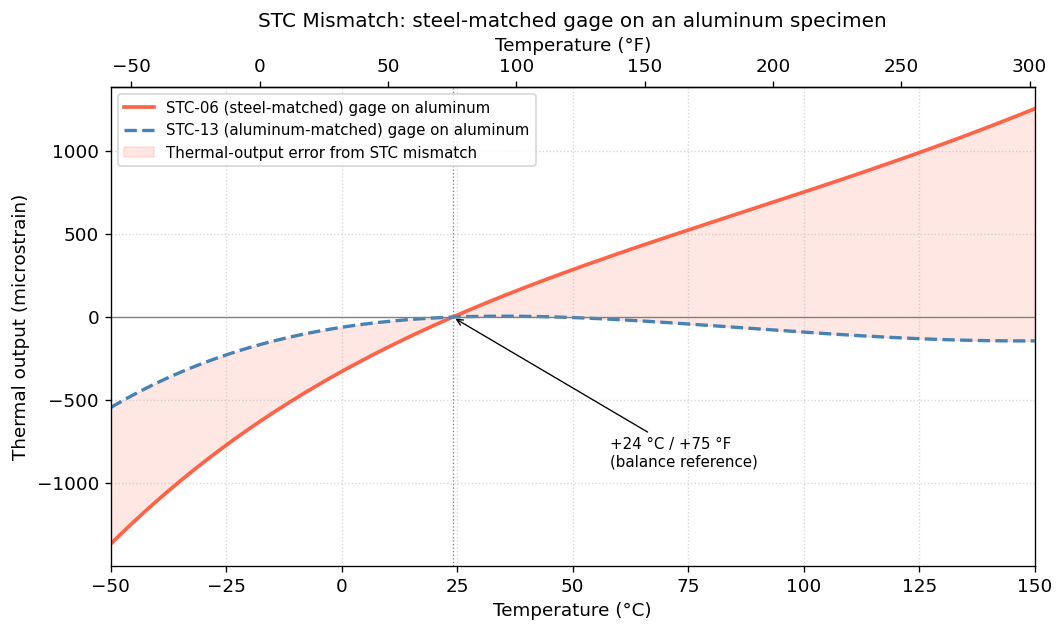

CTE mismatch: 11.1 ppm/degC
At T = 74 degC (dT = 50 degC above reference):
  Mismatch penalty (STC-06 vs STC-13):   555 microstrain
  Residual of the correctly matched gage:   -40 microstrain
  Mismatch penalty equals about 111 MPa of stress in steel.
Note the matched gage is small but not zero -- compensation is not cancellation.


In [3]:
# Steel-matched (STC-06) gage vs. aluminum-matched (STC-13) gage, both on an
# aluminum specimen. The steel-matched gage carries the full expansion
# mismatch; the aluminum-matched gage carries only the compensated residual --
# small near the +24 degC reference, but NOT identically zero elsewhere.
AL_STC_MATCH_CTE = 23.2   # ppm/degC  (STC-13, matched to this specimen)
ALUMINUM_CTE     = 23.2   # ppm/degC  (6061 specimen)
E_STEEL_MPA      = 200e3  # MPa       for the equivalent-stress comparison

T = np.linspace(-50.0, 150.0, 400)  # degC
eps_mismatch = thermal_output(ALUMINUM_CTE, T, STEEL_STC_MATCH_CTE)
eps_matched  = thermal_output(ALUMINUM_CTE, T, AL_STC_MATCH_CTE)

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.plot(T, eps_mismatch, 'tomato', lw=2.2,
        label='STC-06 (steel-matched) gage on aluminum')
ax.plot(T, eps_matched, 'steelblue', lw=2.0, ls='--',
        label='STC-13 (aluminum-matched) gage on aluminum')
ax.fill_between(T, eps_mismatch, eps_matched, alpha=0.15, color='tomato',
                label='Thermal-output error from STC mismatch')
ax.axhline(0, color='0.5', lw=0.8)
ax.axvline(TREF_C, color='0.5', lw=0.8, ls=':')
ax.annotate('+24 °C / +75 °F\n(balance reference)', xy=(TREF_C, 0),
            xytext=(58, -900), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Thermal output (microstrain)')
ax.set_title('STC Mismatch: steel-matched gage on an aluminum specimen')
ax.set_xlim(-50, 150)
secax = ax.secondary_xaxis('top', functions=(c2f, f2c))
secax.set_xlabel('Temperature (°F)')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig19_nb2_stc_mismatch.png', bbox_inches='tight', dpi=300)
plt.show()

# Quantify the mismatch penalty at a 50 degC excursion above the reference.
T_EXAMPLE_C = TREF_C + 50.0
err_ue = abs(thermal_output(ALUMINUM_CTE, T_EXAMPLE_C, STEEL_STC_MATCH_CTE)
             - thermal_output(ALUMINUM_CTE, T_EXAMPLE_C, AL_STC_MATCH_CTE))
resid_ue = thermal_output(ALUMINUM_CTE, T_EXAMPLE_C, AL_STC_MATCH_CTE)
equiv_stress_MPa = (err_ue * 1e-6) * E_STEEL_MPA
print(f"CTE mismatch: {ALUMINUM_CTE - STEEL_STC_MATCH_CTE:.1f} ppm/degC")
print(f"At T = {T_EXAMPLE_C:.0f} degC (dT = 50 degC above reference):")
print(f"  Mismatch penalty (STC-06 vs STC-13): {err_ue:5.0f} microstrain")
print(f"  Residual of the correctly matched gage: {resid_ue:5.0f} microstrain")
print(f"  Mismatch penalty equals about {equiv_stress_MPa:.0f} MPa of stress in steel.")
print("Note the matched gage is small but not zero -- compensation is not cancellation.")

---
## 3 — Temperature Correction Using a Dummy Gage

The dummy gage technique places a second, identical gage on an unstressed piece of the same specimen material, in the same thermal environment as the active gage. Both gages experience the same temperature change and therefore produce the same thermal output. When wired in adjacent bridge arms (half-bridge configuration), the two thermal outputs subtract — leaving only the mechanical strain in the active gage.

The calculation below makes this concrete with numbers: 100 με of true mechanical strain buried under 200 με of thermal output. Without the dummy, the quarter-bridge reads 300 με — a 200% error. With the dummy half-bridge, the reading is exactly 100 με. No mathematical correction is required; the cancellation is built into the bridge circuit itself.

In [4]:
# Dummy-gage (half-bridge) thermal compensation.
#   Active gage: delta_R/R = GF * (eps_mech + eps_thermal_output)
#   Dummy gage:  delta_R/R = GF * (0        + eps_thermal_output)  [same T, no load]
# Wired in adjacent bridge arms, the two thermal outputs subtract at the node,
# leaving only the active gage's mechanical strain -- no math correction needed.

EPS_MECH_UE = 100   # microstrain  true mechanical strain in the active gage
EPS_TO_UE   = 200   # microstrain  thermal output shared by both gages


def bridge_readings(eps_mech, eps_thermal_output):
    """Return (quarter_bridge, half_bridge) indicated strain in microstrain.

    The quarter bridge (single active gage) reads mechanical + thermal output.
    The half bridge with a dummy gage cancels the common thermal output at the
    adjacent bridge arm, so it reads the mechanical strain alone.
    """
    quarter_bridge = eps_mech + eps_thermal_output  # thermal output not removed
    half_bridge    = eps_mech                       # dummy cancels thermal output
    return quarter_bridge, half_bridge


eps_qb, eps_hb = bridge_readings(EPS_MECH_UE, EPS_TO_UE)
error_ue = eps_qb - EPS_MECH_UE

print("Thermal output correction -- dummy gage technique:")
print(f"  True mechanical strain:       {EPS_MECH_UE:6.0f} microstrain")
print(f"  Thermal output (both gages):  {EPS_TO_UE:6.0f} microstrain")
print(f"  Quarter bridge (reads):       {eps_qb:6.0f} microstrain  <- ERROR")
print(f"  Half bridge with dummy:       {eps_hb:6.0f} microstrain  <- CORRECT")
print(f"  Error without correction:     {error_ue:6.0f} microstrain "
      f"({error_ue / EPS_MECH_UE * 100:.0f}%)")

Thermal output correction -- dummy gage technique:
  True mechanical strain:          100 microstrain
  Thermal output (both gages):     200 microstrain
  Quarter bridge (reads):          300 microstrain  <- ERROR
  Half bridge with dummy:          100 microstrain  <- CORRECT
  Error without correction:        200 microstrain (200%)


---
## 4 — Thermal Output by Gage Alloy: A-alloy vs K-alloy

Self-temperature compensation cancels the TCR and expansion-mismatch terms only approximately, and only over a limited range. The residual is a smooth, nonlinear function of temperature whose shape depends on the grid alloy.

The two curves below are **published polynomials for real gage lots**, not modeled shapes. Both carry **STC code 06** — both are compensated for steel — and both are referenced to zero at +24 °C, so the only substantial difference between them is the grid alloy:

| Gage | Grid alloy | Fit order |
|---|---|---|
| `C5K-06-S5145-350/39F` | K-alloy (modified Karma) | 5th |
| `CEA-06-250UW-350` | A-alloy (constantan) | 5th |

Read them for **band width**, not for the value at the reference. Both are near zero at +24 °C, because that is what compensation is for. What separates them is how far the temperature can wander before the residual starts to matter: over +50 to +175 °C the Karma gage stays inside a **26 με** band while the constantan gage swings through **141 με**, and at −50 °C the two read **−205** and **−545 με** respectively.

That is the case for K-alloy in transducer work and wide-temperature installations. It is not a lower thermal output at the balance point — the constantan gage is actually slightly flatter right at the reference — but a much wider band over which the output stays small.


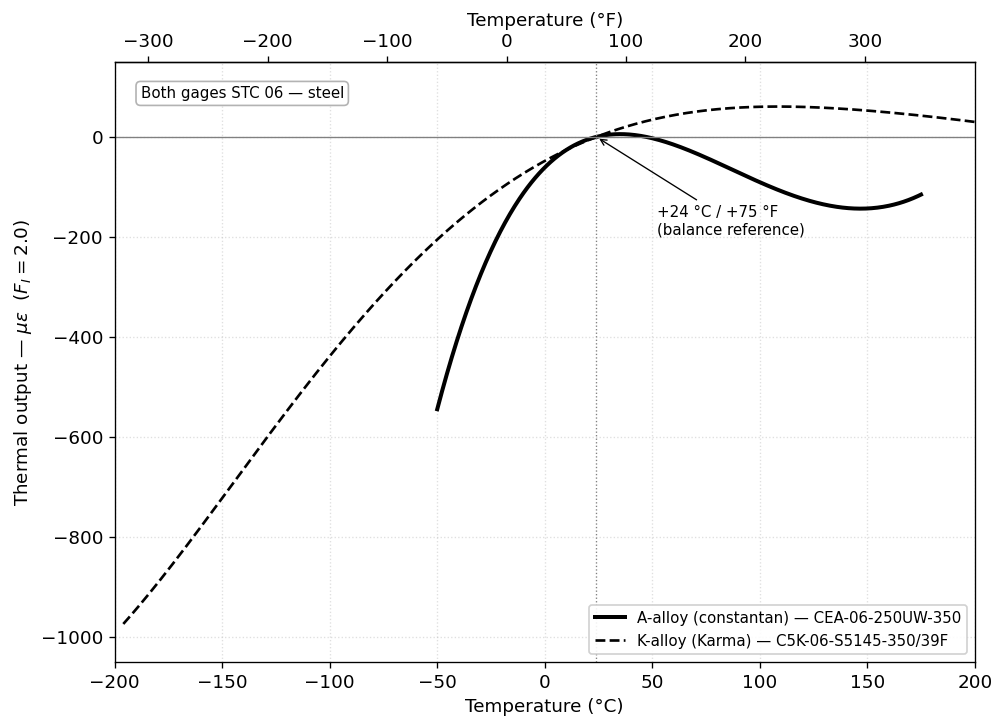

Spread over +50 to +175 degC:
  K-alloy (C5K-06):     26 ue  (+34 to +61)
  A-alloy (CEA-06):    141 ue  (-144 to -3)
At -196 degC: K-alloy -975 ue
At -50 degC:  K-alloy -205 ue   A-alloy -545 ue


In [5]:
# Published thermal output of two STC-06 gages on steel: A-alloy (constantan)
# vs K-alloy (modified Karma). Both polynomials are manufacturer curves for
# real lots, referenced to zero at +24 degC -- the same data Chapter 24 plots
# in Figure 24.1. _cea_06 and _c5k_06 are defined in section 1.
#
# Each curve is drawn only over the range its fit is valid for. A fifth-order
# fit diverges fast outside its data: the CEA curve turns sharply upward past
# about 200 degC and means nothing there. The K-alloy curve runs down to
# -196 degC (-320 degF), liquid-nitrogen temperature.

Tref_C = 24.0  # reference temperature (zero thermal output)

T_K = np.linspace(-196, 200, 500)  # degC -- K-alloy, down to LN2 (-320 degF)
T_A = np.linspace(-50, 175, 500)   # degC -- CEA series service ceiling

yK = _c5k_06(T_K) - _c5k_06(Tref_C)
yA = _cea_06(T_A) - _cea_06(Tref_C)

c2f = lambda c: c * 9/5 + 32
f2c = lambda f: (f - 32) * 5/9

fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.plot(T_A, yA, 'k-', lw=2.4, label='A-alloy (constantan) — CEA-06-250UW-350')
ax.plot(T_K, yK, 'k--', lw=1.6, label='K-alloy (Karma) — C5K-06-S5145-350/39F')
ax.axhline(0, color='0.5', lw=0.8)
ax.axvline(Tref_C, color='0.5', lw=0.8, ls=':')
ax.annotate('+24 °C / +75 °F\n(balance reference)', xy=(Tref_C, 0),
            xytext=(52, -195), fontsize=9, arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel(r'Thermal output — $\mu\varepsilon$  ($F_I = 2.0$)')
ax.set_xlim(-200, 200); ax.set_ylim(-1050, 150)
ax.grid(True, ls=':', alpha=0.4)
secax = ax.secondary_xaxis('top', functions=(c2f, f2c))
secax.set_xlabel('Temperature (°F)')
ax.text(0.03, 0.94, 'Both gages STC 06 — steel', transform=ax.transAxes,
        ha='left', fontsize=9, bbox=dict(boxstyle='round', fc='white', ec='0.7'))
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig19_nb3_thermal_output_alloys.png', bbox_inches='tight', dpi=300)
plt.show()

# Band width is the number that matters for alloy selection.
band = np.linspace(50, 175, 400)
kb = _c5k_06(band) - _c5k_06(Tref_C)
ab = _cea_06(band) - _cea_06(Tref_C)
print(f"Spread over +50 to +175 degC:")
print(f"  K-alloy (C5K-06): {kb.max()-kb.min():6.0f} ue  ({kb.min():+.0f} to {kb.max():+.0f})")
print(f"  A-alloy (CEA-06): {ab.max()-ab.min():6.0f} ue  ({ab.min():+.0f} to {ab.max():+.0f})")
print(f"At -196 degC: K-alloy {_c5k_06(-196)-_c5k_06(Tref_C):+.0f} ue")
print(f"At -50 degC:  K-alloy {_c5k_06(-50)-_c5k_06(Tref_C):+.0f} ue   "
      f"A-alloy {_cea_06(-50)-_cea_06(Tref_C):+.0f} ue")


---
## Where to take this next

This notebook builds thermal output from a published lot polynomial plus a linear expansion-mismatch term. Real thermal output is lot-specific and its mismatch term is itself mildly temperature dependent. Three concrete extensions:

1. **Fit a real lot-specific thermal-output polynomial.** Micro-Measurements ships each gage lot with a cubic thermal-output curve, $\varepsilon_{T/O} = a_0 + a_1 T + a_2 T^2 + a_3 T^3$. Substitute a real lot certificate for the representative curve used here, then differentiate it to plot the local slope (µε/°C) and find the temperature where thermal output is most sensitive — the worst place to operate an uncompensated gage.

2. **Add gage-factor drift.** Layer the multiplicative correction of Eq. 19.3 on top of the additive thermal-output subtraction and reproduce the chapter's worked example: convert the data-sheet thermal output (110 µε, referenced to GF = 2.00) to the instrument setting $F_1 = 2.100$ (104.8 µε), subtract it (425 µε → 320.2 µε), then rescale for gage-factor drift with $F_2 = 2.107$ (→ 319 µε). Show how the two corrections compound as a function of temperature.

3. **Model a real dummy-gage mismatch.** Section 3 assumes the dummy sees exactly the active gage's thermal output. Break that assumption: give the dummy a small temperature offset or a slightly different lot curve, and quantify how much residual thermal output leaks through — the practical limit the chapter warns about for gradients and transients.